<a href="https://colab.research.google.com/github/Ayush28-ai/Ayush28-ai/blob/main/Untitled19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install numpy pandas matplotlib scikit-learn seaborn

In [6]:
!pip install scikit-image opencv-python scikit-learn xgboost pgmpy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 43.4 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss, classification_report, confusion_matrix



In [3]:

!pip install kaggle


In [4]:
from google.colab import files
files.upload()  # Select the kaggle.json file


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"ayushkumarr","key":"b8a6af184d1bd22a87f3c5ddecd47ac7"}'}

In [17]:

!pip install -q kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [19]:

!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): CC0-1.0
 88% 131M/149M [00:00<00:00, 1.36GB/s]
100% 149M/149M [00:00<00:00, 1.32GB/s]


In [21]:

!unzip -q brain-tumor-mri-dataset.zip

replace Testing/glioma/Te-glTr_0000.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace Testing/glioma/Te-glTr_0001.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [29]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neural_network import MLPClassifier
import xgboost as xgb


In [30]:
train_dir = "Training"
test_dir = "Testing"

# Load VGG16 without top layers
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(32,32,3))
model = Model(inputs=base_model.input, outputs=base_model.output)

# Image generator
datagen = ImageDataGenerator(rescale=1./255)
batch_size = 32

# Training generator
train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(32,32),
    batch_size=batch_size,
    class_mode='sparse',
    shuffle=False
)

# Testing generator
test_generator = datagen.flow_from_directory(
    test_dir,
    target_size=(32,32),
    batch_size=batch_size,
    class_mode='sparse',
    shuffle=False
)

# Extract CNN features in batches
X_train = model.predict(train_generator, verbose=1)
y_train = train_generator.classes

X_test = model.predict(test_generator, verbose=1)
y_test = test_generator.classes

# Flatten features
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("CNN feature shape:", X_train.shape)


Found 5712 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


179/179 ━━━━━━━━━━━━━━━━━━━━ 78s 434ms/step
41/41 ━━━━━━━━━━━━━━━━━━━━ 19s 455ms/step
CNN feature shape: (5712, 512)


In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neural_network import MLPClassifier
import xgboost as xgb

# Initialize models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel='linear', probability=True),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "AdaBoost": AdaBoostClassifier(n_estimators=50),
    "MLP": MLPClassifier(hidden_layer_sizes=(128,), max_iter=300)
}

# Train models and store accuracy
results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")


Training Logistic Regression...
Logistic Regression Accuracy: 0.8642
Training KNN...
KNN Accuracy: 0.8650
Training SVM...
SVM Accuracy: 0.8871
Training Naive Bayes...
Naive Bayes Accuracy: 0.4485
Training Decision Tree...
Decision Tree Accuracy: 0.8078
Training Random Forest...
Random Forest Accuracy: 0.8947
Training XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [06:39:30] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.9153
Training AdaBoost...
AdaBoost Accuracy: 0.6812
Training MLP...
MLP Accuracy: 0.9283


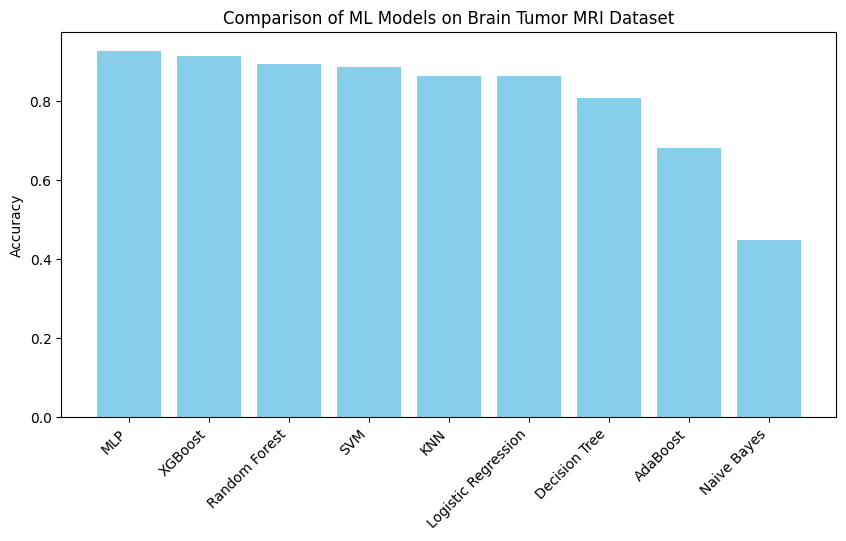

Best model: MLP
              precision    recall  f1-score   support

      glioma       0.91      0.83      0.87       300
  meningioma       0.86      0.90      0.88       306
     notumor       0.99      0.99      0.99       405
   pituitary       0.94      0.97      0.96       300

    accuracy                           0.93      1311
   macro avg       0.92      0.92      0.92      1311
weighted avg       0.93      0.93      0.93      1311



In [32]:
# Sort models by accuracy
sorted_results = dict(sorted(results.items(), key=lambda x: x[1], reverse=True))

# Display results
plt.figure(figsize=(10,5))
plt.bar(sorted_results.keys(), sorted_results.values(), color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel("Accuracy")
plt.title("Comparison of ML Models on Brain Tumor MRI Dataset")
plt.show()

# Print detailed classification report for the best model
best_model_name = max(results, key=results.get)
print(f"Best model: {best_model_name}")
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test)
print(classification_report(y_test, y_pred_best, target_names=le.classes_))


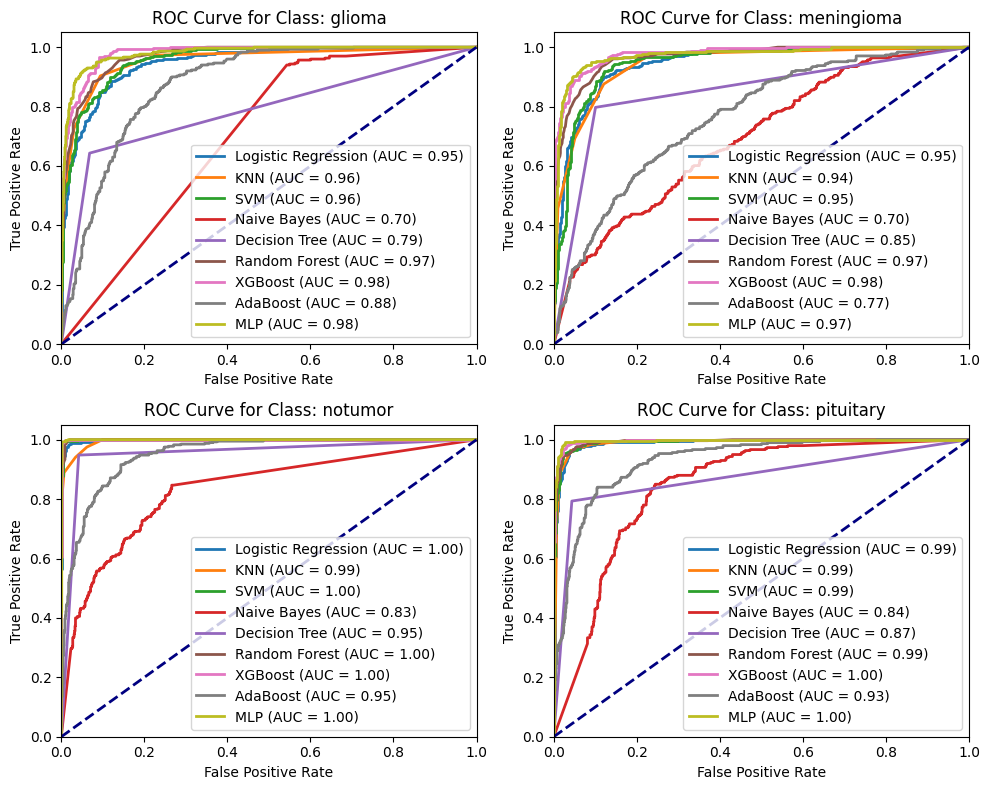

In [35]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Binarize labels for ROC (one-vs-rest)
y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
n_classes = y_test_bin.shape[1]

plt.figure(figsize=(10, 8))

# Plot ROC curve for each class
for i in range(n_classes):
    plt.subplot(2, 2, i + 1) # Create subplots for each class
    for name, model in models.items():
        try:
            # Predict probabilities for the current class
            y_score = model.predict_proba(X_test)[:, i]
        except AttributeError:
            # For models without predict_proba, use decision_function
            # Assuming the order of decision_function output corresponds to class order
            y_score = model.decision_function(X_test)[:, i]

        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve for Class: {le.classes_[i]}')
    plt.legend(loc="lower right")

plt.tight_layout() # Adjust layout to prevent overlap
plt.show()